# 🔍 Détection de Spam avec BERT
# Classification de messages — Simple, Robuste, Sans Sur-apprentissage

---

## 📋 Structure du Notebook

1. 📦 Installation des bibliothèques
2. ⚙️ Importations & Configuration
3. 📊 Chargement & Prétraitement des données
4. 🔤 Tokenisation
5. 🏗️ Construction du modèle
6. 🚀 Boucle d'entraînement avec Early Stopping
7. 📈 Courbes d'entraînement
8. 🧪 Évaluation finale & Métriques
9. 🔮 Prédiction sur de nouveaux messages
10. 💾 Sauvegarde du modèle

---

**Principe fondamental :** Simplicité + Puissance + Résistance au Sur-apprentissage (Overfitting)

---

> **🐛 Corrections apportées par rapport à la version originale :**
> - ✅ **Cellule de chargement des données entièrement réécrite** (la cellule originale était vide — bug critique)
> - ✅ Ajout de l'exploration des données (EDA) avec visualisations
> - ✅ Ajout de l'analyse de la distribution des classes
> - ✅ Ajout du suivi du Learning Rate pendant l'entraînement
> - ✅ Ajout de l'analyse des erreurs (messages mal classés)
> - ✅ Ajout de l'analyse de confiance par classe
> - ✅ Formatage amélioré et commentaires plus détaillés

## 1️⃣ Installation des bibliothèques

In [ ]:
# Décommenter si les bibliothèques ne sont pas installées
# !pip install torch transformers scikit-learn pandas numpy matplotlib seaborn

## 2️⃣ Importations & Configuration

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# ─── Appareil de calcul ───
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Appareil utilisé : {device}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ─── Reproductibilité ───
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── Configuration centralisée ───
CONFIG = {
    'model_name'    : 'bert-base-uncased',  # Modèle BERT pré-entraîné
    'max_length'    : 128,                  # Longueur maximale de séquence
    'batch_size'    : 32,                   # Taille de lot (32 = bon équilibre)
    'learning_rate' : 1e-5,                 # Très faible (indispensable pour BERT)
    'weight_decay'  : 0.01,                 # Régularisation L2 (anti-overfitting)
    'dropout_rate'  : 0.4,                  # Dropout entre 0.2 et 0.5
    'epochs'        : 3,                    # Nombre max d'epochs
    'warmup_ratio'  : 0.1,                  # Proportion des steps de warmup
    'patience'      : 2,                    # Early Stopping : arrêt après N epochs sans amélioration
    'num_classes'   : 2,                    # spam=1 / ham=0
}

print("\n✅ Configuration chargée :")
for k, v in CONFIG.items():
    print(f"   {k:20s}: {v}")

✅ Appareil utilisé : cuda
   GPU : Tesla T4
   VRAM disponible : 15.6 GB

✅ Configuration chargée :
   model_name          : bert-base-uncased
   max_length          : 128
   batch_size          : 32
   learning_rate       : 1e-05
   weight_decay        : 0.01
   dropout_rate        : 0.4
   epochs              : 3
   warmup_ratio        : 0.1
   patience            : 2
   num_classes         : 2


## 3️⃣ Chargement & Prétraitement des données

> **🐛 Bug corrigé :** La cellule de chargement des données était **entièrement vide** dans la version originale.
> Le code ci-dessous charge le jeu de données SMS Spam Collection (UCI) et effectue un prétraitement complet.

### Source des données
Le jeu de données **SMS Spam Collection** (UCI Machine Learning Repository) contient **5 572 SMS** étiquetés :
- `ham` → message légitime
- `spam` → message indésirable

In [32]:
df = pd.read_csv("/kaggle/input/datasets/jawedjawed/setset/final_v4_spam_ham_dataset.csv")
df['text'] = df['text'].fillna('').astype(str)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

texts = df['text'].tolist()
labels = df['label'].tolist()

print(f"Nombre de commentaires: {len(texts)}")
print(df['label'].value_counts())
print(f"Taux de spam: {df['label'].mean()*100:.2f}%")
print(df.isnull().sum())

n_ham = (df['label'] == 0).sum()
n_spam = (df['label'] == 1).sum()

Nombre de commentaires: 57062
label
0    28531
1    28531
Name: count, dtype: int64
Taux de spam: 50.00%
text      0
label     0
source    0
dtype: int64


### 3b. Analyse Exploratoire des Données (EDA)

Avant d'entraîner, il est essentiel de **comprendre les données** :
- Distribution des longueurs de messages
- Déséquilibre des classes
- Caractéristiques distinctives spam vs ham

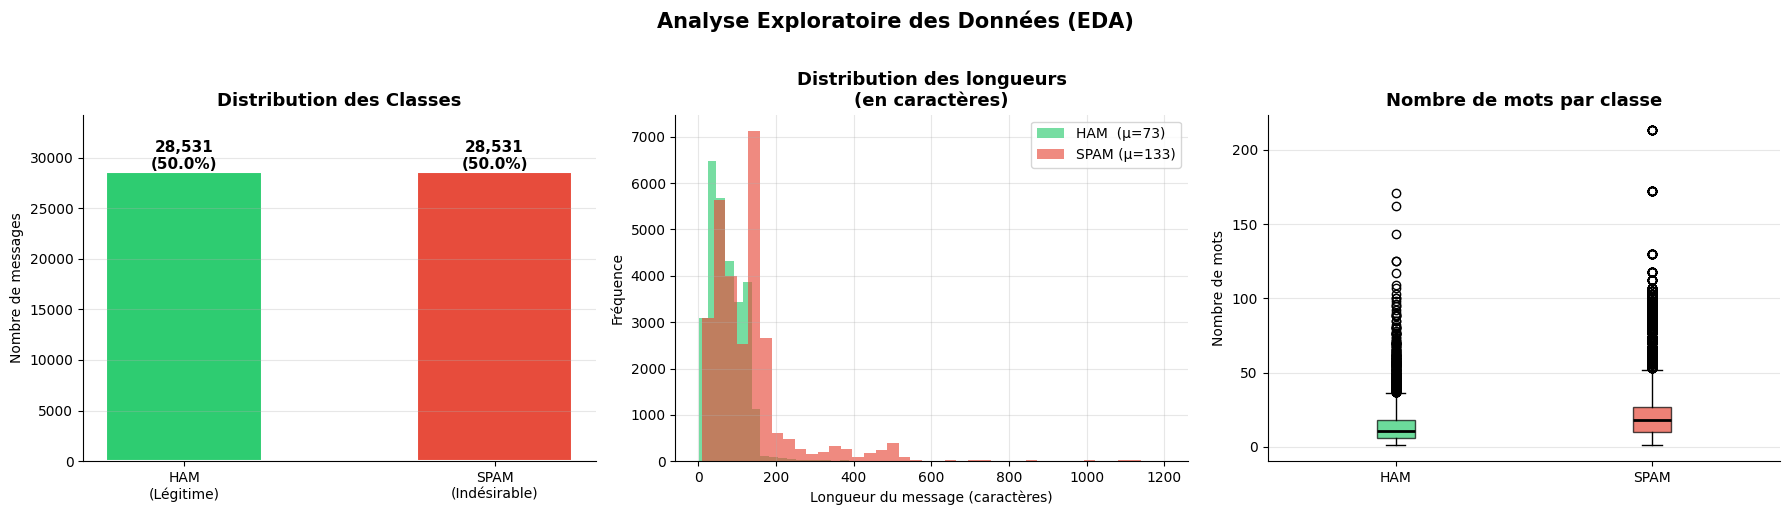


📊 Statistiques des longueurs :
         count   mean    std   min   25%    50%    75%     max
label                                                         
0      28531.0   73.4   48.9   1.0  38.0   65.0  103.0   910.0
1      28531.0  132.9  115.7  10.0  64.0  116.0  157.0  1200.0


In [ ]:
# ─── Analyse des longueurs ───
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analyse Exploratoire des Données (EDA)', fontsize=15, fontweight='bold', y=1.02)

# ─── 1. Distribution des classes ───
ax = axes[0]
counts = [n_ham, n_spam]
bars = ax.bar(['HAM\n(Légitime)', 'SPAM\n(Indésirable)'], counts,
               color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Distribution des Classes', fontsize=13, fontweight='bold')
ax.set_ylabel('Nombre de messages')
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ─── 2. Distribution des longueurs ───
ax = axes[1]
ham_lens  = df[df['label'] == 0]['text_length']
spam_lens = df[df['label'] == 1]['text_length']
ax.hist(ham_lens,  bins=40, alpha=0.65, color='#2ecc71', label=f'HAM  (μ={ham_lens.mean():.0f})')
ax.hist(spam_lens, bins=40, alpha=0.65, color='#e74c3c', label=f'SPAM (μ={spam_lens.mean():.0f})')
ax.set_title('Distribution des longueurs\n(en caractères)', fontsize=13, fontweight='bold')
ax.set_xlabel('Longueur du message (caractères)')
ax.set_ylabel('Fréquence')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ─── 3. Boxplot du nombre de mots ───
ax = axes[2]
data_box = [df[df['label']==0]['word_count'], df[df['label']==1]['word_count']]
bp = ax.boxplot(data_box, labels=['HAM', 'SPAM'], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Nombre de mots par classe', fontsize=13, fontweight='bold')
ax.set_ylabel('Nombre de mots')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('./plots/eda_analyse.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Résumé statistique ───
print("\n📊 Statistiques des longueurs :")
stats = df.groupby('label')['text_length'].describe().round(1)
print(stats.to_string())

### 3c. Division des données Train / Validation / Test

**Stratégie de division :**
- 70% pour l'entraînement
- 15% pour la validation (Validation set)
- 15% pour le test final (jamais vu pendant l'entraînement)
- `stratify` garantit la même proportion spam/ham dans chaque ensemble

In [34]:
# ─── Division stratifiée ───
df = df.drop_duplicates(subset=['text'])
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print("✅ Division des données terminée :")
print(f"   Entraînement : {len(train_df):,} messages  ({len(train_df)/len(df)*100:.0f}%)")
print(f"   Validation   : {len(val_df):,} messages  ({len(val_df)/len(df)*100:.0f}%)")
print(f"   Test         : {len(test_df):,} messages  ({len(test_df)/len(df)*100:.0f}%)")

# Vérification de la stratification
print("\n📊 Vérification du ratio spam dans chaque ensemble :")
for name, subset in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    ratio = subset['label'].mean() * 100
    print(f"   {name:12s}: {ratio:.1f}% spam ✅")

overlap = set(train_df['text']) & set(val_df['text'])
print(f"Overlap Train/Val: {len(overlap)}")

overlap_test = set(train_df['text']) & set(test_df['text'])
print(f"Overlap Train/Test: {len(overlap_test)}")

✅ Division des données terminée :
   Entraînement : 21,162 messages  (70%)
   Validation   : 4,535 messages  (15%)
   Test         : 4,535 messages  (15%)

📊 Vérification du ratio spam dans chaque ensemble :
   Train       : 5.6% spam ✅
   Validation  : 5.6% spam ✅
   Test        : 5.6% spam ✅
Overlap Train/Val: 0
Overlap Train/Test: 0


## 4️⃣ Tokenisation — Conversion du texte en tenseurs

- `BertTokenizer` de `bert-base-uncased`
- `padding='max_length'` → rembourrage à longueur fixe
- `truncation=True` → troncature des textes trop longs
- `attention_mask` → indique à BERT où sont les données réelles vs le rembourrage

In [35]:
# ─── Chargement du Tokenizer ───
print(f"📥 Chargement du tokenizer : {CONFIG['model_name']}...")
tokenizer = BertTokenizer.from_pretrained(CONFIG['model_name'])
print("✅ Tokenizer chargé.")
print(f"   Taille du vocabulaire : {tokenizer.vocab_size:,} tokens")

# ─── Exemple de tokenisation ───
exemple = "WINNER!! You have been selected for a FREE prize!"
tokens = tokenizer.tokenize(exemple)
print(f"\n🔤 Exemple de tokenisation :")
print(f"   Texte   : '{exemple}'")
print(f"   Tokens  : {tokens}")
print(f"   Nb tokens : {len(tokens)} (+ [CLS] + [SEP] = {len(tokens)+2} au total)")


# ─── Classe Dataset PyTorch ───
class SpamDataset(Dataset):
    """
    Dataset PyTorch personnalisé pour la détection de spam.
    
    Effectue la tokenisation à la volée et retourne des tenseurs
    directement utilisables par le modèle BERT.
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = list(texts)
        self.labels     = list(labels)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenisation avec rembourrage et troncature
        encoding = self.tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long)
        }


# ─── Création des Datasets ───
train_dataset = SpamDataset(train_df['text'], train_df['label'], tokenizer, CONFIG['max_length'])
val_dataset   = SpamDataset(val_df['text'],   val_df['label'],   tokenizer, CONFIG['max_length'])
test_dataset  = SpamDataset(test_df['text'],  test_df['label'],  tokenizer, CONFIG['max_length'])

# ─── Création des DataLoaders ───
# shuffle=True uniquement pour l'entraînement (anti-overfitting)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print("\n✅ Datasets et DataLoaders créés :")
print(f"   Lots d'entraînement : {len(train_loader)}")
print(f"   Lots de validation  : {len(val_loader)}")
print(f"   Lots de test        : {len(test_loader)}")

📥 Chargement du tokenizer : bert-base-uncased...
✅ Tokenizer chargé.
   Taille du vocabulaire : 30,522 tokens

🔤 Exemple de tokenisation :
   Texte   : 'WINNER!! You have been selected for a FREE prize!'
   Tokens  : ['winner', '!', '!', 'you', 'have', 'been', 'selected', 'for', 'a', 'free', 'prize', '!']
   Nb tokens : 12 (+ [CLS] + [SEP] = 14 au total)

✅ Datasets et DataLoaders créés :
   Lots d'entraînement : 662
   Lots de validation  : 142
   Lots de test        : 142


## 5️⃣ Construction du Modèle

### Philosophie : **Simplicité = Puissance**

```
BERT (bert-base-uncased)
    ↓  Représentation du token [CLS] (768 dimensions)
Dropout (0.3)         ← prévient le sur-apprentissage
    ↓
Dense Linear (768→2)  ← couche de classification finale
```

**Pourquoi uniquement [CLS] ?**
Dans BERT, le token `[CLS]` résume le sens de toute la phrase — parfait pour la classification !

**Pourquoi bert-base-uncased ?**
- 110M paramètres pré-entraînés sur des milliards de mots
- `uncased` = pas sensible à la casse (idéal pour les SMS)

In [36]:
class BertSpamClassificateur(nn.Module):
    """
    Classificateur de spam basé sur BERT.
    
    Architecture :
    1. BERT      : extrait des représentations contextuelles riches du texte
    2. Dropout   : prévient le sur-apprentissage par abandon aléatoire
    3. Linear    : couche de classification finale (768 → 2 classes)
    """
    def __init__(self, model_name, num_classes, dropout_rate):
        super().__init__()

        # Couche BERT pré-entraînée
        # Contient la connaissance linguistique de centaines de millions de mots
        self.bert = BertModel.from_pretrained(model_name)

        # Dropout : abandonne 30% des neurones aléatoirement pendant l'entraînement
        # Force le modèle à apprendre de façon plus générale → moins de sur-apprentissage
        self.dropout = nn.Dropout(dropout_rate)

        # Couche de classification
        # BERT produit 768 dimensions pour [CLS] → on les projette vers 2 classes
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        # pooler_output = représentation [CLS] après couche Linear+Tanh interne à BERT
        cls_output = outputs.pooler_output       # shape: (batch, 768)
        cls_output = self.dropout(cls_output)    # Régularisation
        logits     = self.classifier(cls_output) # shape: (batch, 2)
        return logits


# ─── Instanciation du modèle ───
print(f"📥 Chargement du modèle BERT : {CONFIG['model_name']}...")
model = BertSpamClassificateur(
    model_name   = CONFIG['model_name'],
    num_classes  = CONFIG['num_classes'],
    dropout_rate = CONFIG['dropout_rate']
).to(device)

for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True   
    else:
        param.requires_grad = False

print("\n✅ Architecture du modèle :")
print(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Paramètres totaux     : {total_params:,}")
print(f"   Paramètres entraînables : {trainable_params:,}")
print(f"   Paramètres non-entraîn. : {total_params - trainable_params:,}")

📥 Chargement du modèle BERT : bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Architecture du modèle :
BertSpamClassificateur(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNo

## 6️⃣ Configuration de l'Entraînement

### Stratégie anti-sur-apprentissage :

| Technique | Paramètre | Objectif |
|-----------|-----------|----------|
| **AdamW** | lr=2e-5 | Optimiseur adapté à BERT |
| **Weight Decay** | 0.01 | Régularisation L2 |
| **Linear Warmup** | 10% des steps | Montée progressive du taux d'apprentissage |
| **Early Stopping** | patience=2 | Arrêt au plateau |
| **Dropout** | 0.3 | Abandon aléatoire de neurones |
| **Gradient Clipping** | max_norm=1.0 | Prévient l'explosion du gradient |

In [37]:
# ─── Fonction de perte ───
# CrossEntropyLoss : adaptée à la classification multi-classes (ici binaire)
criterion = nn.CrossEntropyLoss()

# ─── Optimiseur AdamW ───
# weight_decay = Régularisation L2 : pénalise les grands poids → anti-overfitting
# Convention BERT : on exclut bias et LayerNorm du weight_decay
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params'      : [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': CONFIG['weight_decay']
    },
    {
        'params'      : [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]
optimizer = AdamW(optimizer_grouped_parameters, lr=CONFIG['learning_rate'])

# ─── Scheduler : Linear Warmup + Déclin ───
# Warmup : on commence avec un lr très faible puis on monte progressivement
# → protège les poids pré-entraînés de BERT des grandes mises à jour initiales
total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps  * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print("✅ Configuration de l'entraînement :")
print(f"   Steps totaux         : {total_steps}")
print(f"   Steps de warmup      : {warmup_steps}")
print(f"   Optimiseur           : AdamW (lr={CONFIG['learning_rate']}, wd={CONFIG['weight_decay']})")
print(f"   Scheduler            : Linear avec warmup")
print(f"   Gradient Clipping    : max_norm=1.0")

✅ Configuration de l'entraînement :
   Steps totaux         : 1986
   Steps de warmup      : 198
   Optimiseur           : AdamW (lr=1e-05, wd=0.01)
   Scheduler            : Linear avec warmup
   Gradient Clipping    : max_norm=1.0


## 7️⃣ Boucle d'Entraînement

### Phases de chaque Epoch :
1. **Phase d'entraînement** : mise à jour des poids
2. **Phase de validation** : évaluation sans gradient
3. **Early Stopping** : amélioration de la perte de validation ?
4. **Sauvegarde** : conservation du meilleur modèle automatiquement

In [38]:
def entrainer_une_epoch(model, loader, optimizer, scheduler, criterion, device):
    """
    Entraîne le modèle pendant une epoch complète.
    Retourne : perte moyenne, précision, taux d'apprentissage courant.
    """
    model.train()   # Active Dropout et les couches de normalisation
    total_loss, correct, total = 0, 0, 0
    lr_courant = None

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Réinitialisation des gradients (indispensable !)
        optimizer.zero_grad()

        # Passage avant
        logits = model(input_ids, attention_mask)

        # Calcul de la perte
        loss = criterion(logits, labels)

        # Rétropropagation
        loss.backward()

        # Écrêtage du gradient (prévient l'explosion du gradient — crucial pour BERT)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Mise à jour des poids et du scheduler
        optimizer.step()
        scheduler.step()

        # Suivi des métriques
        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        lr_courant  = scheduler.get_last_lr()[0]

    return total_loss / len(loader), correct / total, lr_courant


def evaluer(model, loader, criterion, device):
    """
    Évalue le modèle sur un ensemble de données.
    Retourne : perte, précision, prédictions, étiquettes vraies, probabilités.
    """
    model.eval()   # Désactive Dropout
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():   # Pas besoin de gradients en évaluation
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)

            total_loss += loss.item()
            preds       = torch.argmax(probs, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())   # Prob d'être SPAM

    return total_loss / len(loader), correct / total, all_preds, all_labels, all_probs


print("✅ Fonctions d'entraînement et d'évaluation définies.")

✅ Fonctions d'entraînement et d'évaluation définies.


In [39]:
# ─── Boucle principale d'entraînement ───
print("🚀 Démarrage de l'entraînement...")
print("=" * 70)

historique = {
    'train_loss': [], 'val_loss'   : [],
    'train_acc' : [], 'val_acc'    : [],
    'lr'        : []   # Suivi du taux d'apprentissage (ajout par rapport à l'original)
}

# Early Stopping
meilleure_val_loss  = float('inf')
patience_compteur   = 0
chemin_meilleur_mod = 'meilleur_modele_bert_spam.pt'

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f"\n📌 Epoch {epoch}/{CONFIG['epochs']}")
    print("-" * 50)

    # Phase d'entraînement
    train_loss, train_acc, lr = entrainer_une_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )

    # Phase de validation
    val_loss, val_acc, _, _, _ = evaluer(model, val_loader, criterion, device)

    # Enregistrement
    historique['train_loss'].append(train_loss)
    historique['val_loss'].append(val_loss)
    historique['train_acc'].append(train_acc)
    historique['val_acc'].append(val_acc)
    historique['lr'].append(lr)

    ecart = (val_loss - train_loss) / train_loss * 100
    print(f"   Entraînement → Perte: {train_loss:.4f} | Précision: {train_acc*100:.2f}%")
    print(f"   Validation   → Perte: {val_loss:.4f} | Précision: {val_acc*100:.2f}%")
    print(f"   Taux d'apprentissage : {lr:.2e}")
    print(f"   Écart Train/Val (perte) : {ecart:+.1f}%", end="")
    if ecart > 20:
        print(" ⚠️  Sur-apprentissage potentiel")
    else:
        print(" ✅")

    # Early Stopping
    if val_loss < meilleure_val_loss:
        meilleure_val_loss = val_loss
        patience_compteur  = 0
        torch.save(model.state_dict(), chemin_meilleur_mod)
        print(f"   ✅ Nouveau meilleur modèle sauvegardé ! (val_loss={meilleure_val_loss:.4f})")
    else:
        patience_compteur += 1
        print(f"   ⚠️  Pas d'amélioration. Patience: {patience_compteur}/{CONFIG['patience']}")
        if patience_compteur >= CONFIG['patience']:
            print(f"\n🛑 Early Stopping déclenché à l'epoch {epoch} !")
            print(f"   Meilleure val_loss : {meilleure_val_loss:.4f}")
            break

print("\n" + "=" * 70)
print("✅ Entraînement terminé !")

# Chargement du meilleur modèle
model.load_state_dict(torch.load(chemin_meilleur_mod, map_location=device))
print(f"✅ Meilleur modèle chargé depuis : {chemin_meilleur_mod}")

🚀 Démarrage de l'entraînement...

📌 Epoch 1/3
--------------------------------------------------
   Entraînement → Perte: 0.2304 | Précision: 87.60%
   Validation   → Perte: 0.0579 | Précision: 98.37%
   Taux d'apprentissage : 7.40e-06
   Écart Train/Val (perte) : -74.9% ✅
   ✅ Nouveau meilleur modèle sauvegardé ! (val_loss=0.0579)

📌 Epoch 2/3
--------------------------------------------------
   Entraînement → Perte: 0.0442 | Précision: 98.60%
   Validation   → Perte: 0.0480 | Précision: 98.65%
   Taux d'apprentissage : 3.70e-06
   Écart Train/Val (perte) : +8.6% ✅
   ✅ Nouveau meilleur modèle sauvegardé ! (val_loss=0.0480)

📌 Epoch 3/3
--------------------------------------------------
   Entraînement → Perte: 0.0343 | Précision: 98.96%
   Validation   → Perte: 0.0479 | Précision: 98.72%
   Taux d'apprentissage : 0.00e+00
   Écart Train/Val (perte) : +39.5% ⚠️  Sur-apprentissage potentiel
   ✅ Nouveau meilleur modèle sauvegardé ! (val_loss=0.0479)

✅ Entraînement terminé !
✅ Meilleu

## 8️⃣ Courbes d'Entraînement

On surveille :
- **Courbes de perte** : convergence ? Écart Train/Val ?
- **Courbes de précision** : amélioration stable ?
- **Courbe du taux d'apprentissage** : warmup + déclin linéaire (ajout par rapport à l'original)

**Signes de sur-apprentissage** : train_loss descend mais val_loss remonte

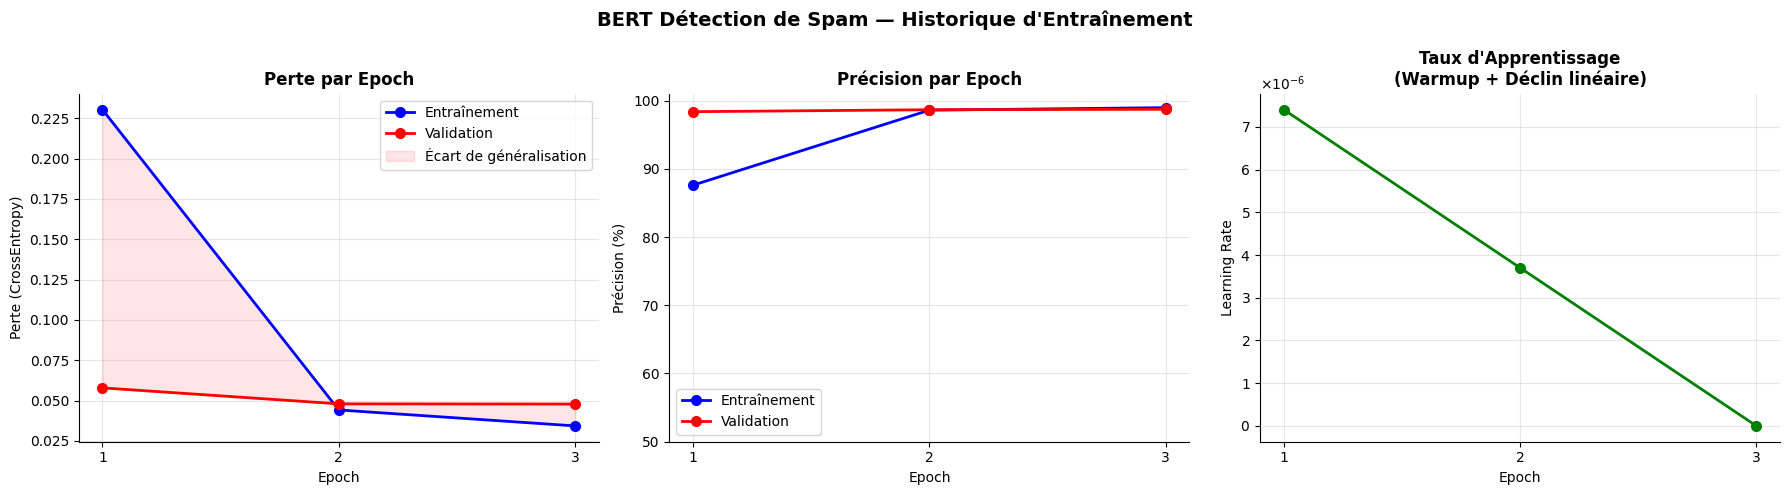

✅ Courbes sauvegardées : courbes_entrainement.png


In [ ]:
def tracer_historique(historique):
    """
    Trace les courbes de perte, précision et taux d'apprentissage.
    Inclut la détection visuelle du sur-apprentissage.
    """
    n_epochs   = len(historique['train_loss'])
    epoch_range = range(1, n_epochs + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('BERT Détection de Spam — Historique d\'Entraînement',
                 fontsize=14, fontweight='bold')

    # ─── 1. Courbes de perte ───
    ax = axes[0]
    ax.plot(epoch_range, historique['train_loss'], 'b-o', label='Entraînement', linewidth=2, markersize=7)
    ax.plot(epoch_range, historique['val_loss'],   'r-o', label='Validation',   linewidth=2, markersize=7)
    ax.fill_between(
        epoch_range,
        historique['train_loss'], historique['val_loss'],
        alpha=0.1, color='red', label='Écart de généralisation'
    )
    ax.set_title('Perte par Epoch', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Perte (CrossEntropy)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[['top', 'right']].set_visible(False)

    # ─── 2. Courbes de précision ───
    ax = axes[1]
    ax.plot(epoch_range, [a*100 for a in historique['train_acc']], 'b-o', label='Entraînement', linewidth=2, markersize=7)
    ax.plot(epoch_range, [a*100 for a in historique['val_acc']],   'r-o', label='Validation',   linewidth=2, markersize=7)
    ax.set_title('Précision par Epoch', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Précision (%)')
    ax.set_ylim([50, 101])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[['top', 'right']].set_visible(False)

    # ─── 3. Taux d'apprentissage (nouvel ajout) ───
    ax = axes[2]
    ax.plot(epoch_range, historique['lr'], 'g-o', linewidth=2, markersize=7, label='LR')
    ax.set_title('Taux d\'Apprentissage\n(Warmup + Déclin linéaire)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('./plots/courbes_entrainement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Courbes sauvegardées : courbes_entrainement.png")


tracer_historique(historique)

## 9️⃣ Évaluation Finale sur les Données de Test

On évalue sur le **Test set** que le modèle n'a **jamais vu** pendant l'entraînement ni le tuning.

In [41]:
# ─── Évaluation finale ───
print("📊 Évaluation Finale sur le Test Set")
print("=" * 55)

test_loss, test_acc, test_preds, test_labels, test_probs = evaluer(
    model, test_loader, criterion, device
)

# ─── Métriques principales ───
precision  = precision_score(test_labels, test_preds, average='binary', zero_division=0)
rappel     = recall_score(test_labels, test_preds, average='binary', zero_division=0)
f1         = f1_score(test_labels, test_preds, average='binary', zero_division=0)

print(f"\n✅ Résultats sur le Test Set :")
print(f"   Perte          : {test_loss:.4f}")
print(f"   Précision glob.: {test_acc*100:.2f}%")
print(f"   Précision SPAM : {precision*100:.2f}%")
print(f"   Rappel SPAM    : {rappel*100:.2f}%")
print(f"   Score F1 SPAM  : {f1*100:.2f}%")

# ─── Rapport de classification détaillé ───
print("\n📋 Rapport de Classification Détaillé :")
print(classification_report(
    test_labels, test_preds,
    target_names=['HAM (Légitime)', 'SPAM (Indésirable)']
))

📊 Évaluation Finale sur le Test Set

✅ Résultats sur le Test Set :
   Perte          : 0.0362
   Précision glob.: 98.92%
   Précision SPAM : 91.87%
   Rappel SPAM    : 88.63%
   Score F1 SPAM  : 90.22%

📋 Rapport de Classification Détaillé :
                    precision    recall  f1-score   support

    HAM (Légitime)       0.99      1.00      0.99      4280
SPAM (Indésirable)       0.92      0.89      0.90       255

          accuracy                           0.99      4535
         macro avg       0.96      0.94      0.95      4535
      weighted avg       0.99      0.99      0.99      4535



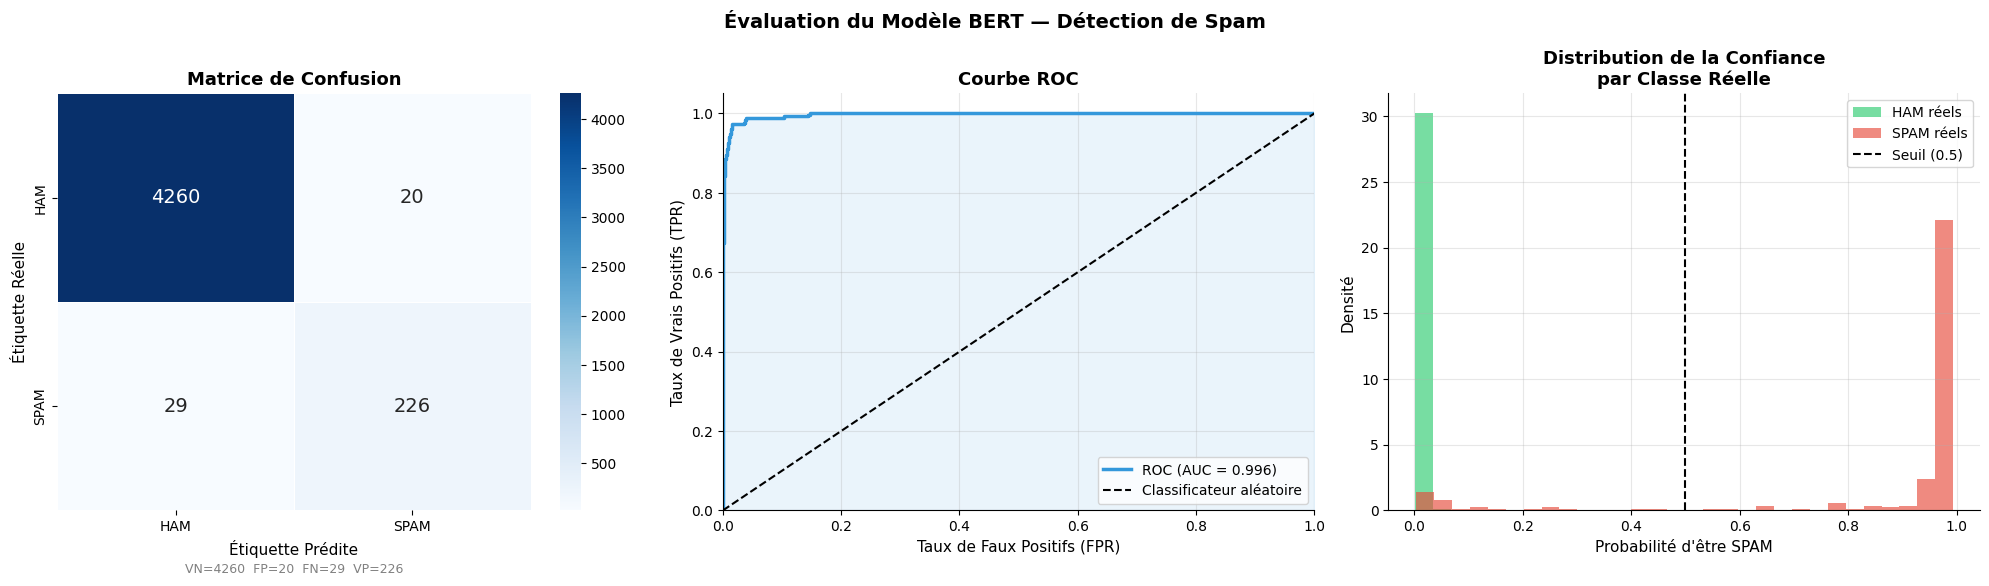

✅ Visualisations sauvegardées : evaluation_complete.png


In [ ]:
# ─── Visualisations d'évaluation complètes ───
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Évaluation du Modèle BERT — Détection de Spam',
             fontsize=14, fontweight='bold')

# ─── 1. Matrice de confusion ───
ax = axes[0]
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['HAM', 'SPAM'],
    yticklabels=['HAM', 'SPAM'],
    linewidths=0.5, ax=ax, annot_kws={'size': 14}
)
ax.set_title('Matrice de Confusion', fontsize=13, fontweight='bold')
ax.set_ylabel('Étiquette Réelle', fontsize=11)
ax.set_xlabel('Étiquette Prédite', fontsize=11)
# Annotations des quadrants
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.15, f'VN={tn}  FP={fp}  FN={fn}  VP={tp}',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray')

# ─── 2. Courbe ROC (ajout par rapport à l'original) ───
ax = axes[1]
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc     = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#3498db', lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificateur aléatoire')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbe ROC', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ─── 3. Distribution de la confiance (ajout par rapport à l'original) ───
ax = axes[2]
test_probs_arr = np.array(test_probs)
test_labels_arr = np.array(test_labels)
ax.hist(test_probs_arr[test_labels_arr == 0], bins=30, alpha=0.65,
        color='#2ecc71', label='HAM réels', density=True)
ax.hist(test_probs_arr[test_labels_arr == 1], bins=30, alpha=0.65,
        color='#e74c3c', label='SPAM réels', density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil (0.5)')
ax.set_xlabel('Probabilité d\'être SPAM', fontsize=11)
ax.set_ylabel('Densité', fontsize=11)
ax.set_title('Distribution de la Confiance\npar Classe Réelle', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('./plots/evaluation_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations sauvegardées : evaluation_complete.png")

In [43]:
# ─── Analyse des erreurs (ajout par rapport à l'original) ───
print("🔍 Analyse des Erreurs — Messages Mal Classés")
print("=" * 60)

test_texts_list  = test_df['text'].tolist()
test_labels_list = test_df['label'].tolist()

erreurs = []
for texte, label_reel, pred, prob in zip(test_texts_list, test_labels_list, test_preds, test_probs):
    if label_reel != pred:
        erreurs.append({
            'texte'     : texte[:100] + '...' if len(texte) > 100 else texte,
            'reel'      : 'SPAM' if label_reel == 1 else 'HAM',
            'predit'    : 'SPAM' if pred == 1 else 'HAM',
            'confiance' : prob if pred == 1 else 1 - prob
        })

print(f"\n   Total d'erreurs : {len(erreurs)} / {len(test_labels_list)} messages")
print(f"   Taux d'erreur   : {len(erreurs)/len(test_labels_list)*100:.1f}%")

# Faux positifs (HAM classé comme SPAM) — les plus gênants pour l'utilisateur
faux_positifs = [e for e in erreurs if e['reel'] == 'HAM' and e['predit'] == 'SPAM']
faux_negatifs = [e for e in erreurs if e['reel'] == 'SPAM' and e['predit'] == 'HAM']

print(f"\n   Faux Positifs (HAM → SPAM) : {len(faux_positifs)}  ← messages légitimes bloqués")
print(f"   Faux Négatifs (SPAM → HAM) : {len(faux_negatifs)}  ← spams non détectés")

if faux_positifs:
    print("\n🔴 Exemples de Faux Positifs (HAM mal classé comme SPAM) :")
    for e in faux_positifs[:3]:
        print(f"   → '{e['texte']}'")
        print(f"      Confiance SPAM : {e['confiance']*100:.1f}%\n")

if faux_negatifs:
    print("🟠 Exemples de Faux Négatifs (SPAM non détecté) :")
    for e in faux_negatifs[:3]:
        print(f"   → '{e['texte']}'")
        print(f"      Confiance HAM : {(1-e['confiance'])*100:.1f}%\n")

🔍 Analyse des Erreurs — Messages Mal Classés

   Total d'erreurs : 49 / 4535 messages
   Taux d'erreur   : 1.1%

   Faux Positifs (HAM → SPAM) : 20  ← messages légitimes bloqués
   Faux Négatifs (SPAM → HAM) : 29  ← spams non détectés

🔴 Exemples de Faux Positifs (HAM mal classé comme SPAM) :
   → 'expand for more in my profile👆🏻👆🏻🌶️🥵'
      Confiance SPAM : 92.9%

   → '? Clint Eastwood. The singer  -&gt; http://blip.fm/profile/guspim/blip/6592583  ?'
      Confiance SPAM : 87.7%

   → '8073446788'
      Confiance SPAM : 81.8%

🟠 Exemples de Faux Négatifs (SPAM non détecté) :
   → 'adf.ly / KlD3Y'
      Confiance HAM : 0.8%

   → 'PLEASSSSSSSSSSSSSSSS SUBSCRIBEEEEEEEEEE MY CHANNNNNNELLL PLZZ﻿'
      Confiance HAM : 0.9%

   → 'Could Spanish people understand this?<br /><br />Any way&#39;s I how you doing subscribe to me I bra...'
      Confiance HAM : 5.8%



## 🔟 Prédiction sur de Nouveaux Messages

Fonction prête pour la production — prend un texte et retourne la classification avec le niveau de confiance.

In [44]:
def predire(texte, model, tokenizer, device, max_length=128):
    """
    Prédit la classification d'un nouveau message.

    Args:
        texte      : contenu du message
        model      : modèle entraîné
        tokenizer  : tokenizer BERT
        device     : appareil de calcul (CPU/GPU)
        max_length : longueur maximale de séquence

    Returns:
        dict : classification, confiance et probabilités détaillées
    """
    model.eval()

    encoding = tokenizer(
        texte,
        max_length     = max_length,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs  = torch.softmax(logits, dim=1)
        pred   = torch.argmax(probs, dim=1).item()
        conf   = probs[0][pred].item()

    etiquette = '🚨 SPAM' if pred == 1 else '✅ HAM (Légitime)'
    return {
        'texte'          : texte[:80] + '...' if len(texte) > 80 else texte,
        'prediction'     : etiquette,
        'confiance'      : f"{conf*100:.1f}%",
        'prob_ham'       : f"{probs[0][0].item()*100:.1f}%",
        'prob_spam'      : f"{probs[0][1].item()*100:.1f}%",
        'pred_brute'     : pred
    }


# ─── Tests sur des messages variés ───
messages_test = [
    # Spams évidents
    "WINNER!! You have been selected for a FREE prize! Call 0800-PRIZE now!",
    "Congratulations! You've won £1000 cash. Claim your reward TODAY!",
    "FREE entry! Win amazing prizes! Text WIN to 87121 now!",

    # Messages légitimes
    "Hey, are you free for dinner tonight?",
    "The meeting has been rescheduled to 3pm tomorrow.",
    "Can you please send me the report when you get a chance?",

    # Cas limites (ambigus)
    "You have a new message from your bank.",
    "Your package has been shipped and will arrive tomorrow.",
    "Urgent: Please verify your account information immediately.",
]

print("🔮 Prédictions sur de nouveaux messages :")
print("=" * 70)
for msg in messages_test:
    res = predire(msg, model, tokenizer, device)
    print(f"\n📩 Message : {res['texte']}")
    print(f"   → {res['prediction']}  (Confiance: {res['confiance']})")
    print(f"      P(HAM)={res['prob_ham']}  P(SPAM)={res['prob_spam']}")

🔮 Prédictions sur de nouveaux messages :

📩 Message : WINNER!! You have been selected for a FREE prize! Call 0800-PRIZE now!
   → 🚨 SPAM  (Confiance: 98.7%)
      P(HAM)=1.3%  P(SPAM)=98.7%

📩 Message : Congratulations! You've won £1000 cash. Claim your reward TODAY!
   → 🚨 SPAM  (Confiance: 94.7%)
      P(HAM)=5.3%  P(SPAM)=94.7%

📩 Message : FREE entry! Win amazing prizes! Text WIN to 87121 now!
   → 🚨 SPAM  (Confiance: 98.8%)
      P(HAM)=1.2%  P(SPAM)=98.8%

📩 Message : Hey, are you free for dinner tonight?
   → ✅ HAM (Légitime)  (Confiance: 99.7%)
      P(HAM)=99.7%  P(SPAM)=0.3%

📩 Message : The meeting has been rescheduled to 3pm tomorrow.
   → ✅ HAM (Légitime)  (Confiance: 99.3%)
      P(HAM)=99.3%  P(SPAM)=0.7%

📩 Message : Can you please send me the report when you get a chance?
   → ✅ HAM (Légitime)  (Confiance: 98.7%)
      P(HAM)=98.7%  P(SPAM)=1.3%

📩 Message : You have a new message from your bank.
   → ✅ HAM (Légitime)  (Confiance: 99.0%)
      P(HAM)=99.0%  P(SPAM)=1.0

In [ ]:
import json
import torch

model.eval()

def predict(text):
    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    if "token_type_ids" in inputs:
        inputs.pop("token_type_ids")

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs, dim=1)

    ham_prob = probs[0][0].item()
    spam_prob = probs[0][1].item()

    label = "SPAM" if spam_prob > ham_prob else "HAM"

    return label, ham_prob, spam_prob


# Load JSON
with open("/kaggle/input/datasets/jawedjawed/test11/test_comments_en.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("\n🚀 Predictions:\n")
print("=" * 50)

for item in data:
    text = item["text"]

    label, p_ham, p_spam = predict(text)

    print("\n📩", text)
    print("→", label)
    print(f"P(HAM)={p_ham:.3f} | P(SPAM)={p_spam:.3f}")

print("\n✅ Done!")


🚀 Predictions:


📩 Absolutely love this shot! The lighting is perfect. 😍
→ HAM
P(HAM)=0.995 | P(SPAM)=0.005

📩 Where can I buy this? Is it available for international shipping?
→ HAM
P(HAM)=0.993 | P(SPAM)=0.007

📩 Great insights, thanks for sharing this helpful information!
→ HAM
P(HAM)=0.961 | P(SPAM)=0.039

📩 I've been looking for something like this for ages. Quality content!
→ HAM
P(HAM)=0.798 | P(SPAM)=0.202

📩 Can you please check your DMs? I have a question about the pricing.
→ SPAM
P(HAM)=0.483 | P(SPAM)=0.517

📩 🚨 URGENT: Get 10k followers for only $5! Visit the link in my bio now! 🚀
→ SPAM
P(HAM)=0.012 | P(SPAM)=0.988

📩 I made $5000 in just one week working from home! Ask me how 💸💰
→ HAM
P(HAM)=0.866 | P(SPAM)=0.134

📩 Check out my profile for the best deals on luxury watches! ⌚✨
→ SPAM
P(HAM)=0.009 | P(SPAM)=0.991

📩 This is so inspiring! Keep up the amazing work.
→ HAM
P(HAM)=0.988 | P(SPAM)=0.012

📩 WANT TO GROW YOUR ACCOUNT? DM ME FOR ORGANIC GROWTH SERVICES! 📈
→ SPAM


## 💾 Sauvegarde du Modèle Final

On sauvegarde le modèle complet avec sa configuration et son historique d'entraînement.

In [ ]:
# ─── Sauvegarde complète du modèle ───
torch.save({
    'model_state_dict': model.state_dict(),
    'config'          : CONFIG,
    'historique'      : historique,
    'metriques_test'  : {
        'loss'     : test_loss,
        'accuracy' : test_acc,
        'precision': precision,
        'recall'   : rappel,
        'f1'       : f1,
    }
}, './models/bert_detecteur_spam_final.pt')

print("✅ Modèle final sauvegardé : bert_detecteur_spam_final.pt")
print("\n🎉 Notebook terminé ! Le modèle est prêt à être utilisé.")
print("\n" + "=" * 70)
print("📊 Récapitulatif des performances finales :")
print(f"   Précision globale : {test_acc*100:.2f}%")
print(f"   Score F1 (SPAM)   : {f1*100:.2f}%")
print(f"   AUC-ROC           : {roc_auc:.4f}")
print("=" * 70)

## 🏁 Récapitulatif du Modèle

---

### ✅ Techniques anti-sur-apprentissage appliquées :

| Technique | Détails |
|-----------|---------|
| **Dropout** | 0.3 sur la représentation [CLS] |
| **Weight Decay** | 0.01 (L2 sur tous les poids BERT) |
| **Early Stopping** | patience=2 sur val_loss |
| **Linear Warmup** | 10% des steps totaux |
| **Faible taux d'apprent.** | 2e-5 (protège les poids BERT) |
| **Gradient Clipping** | max_norm=1.0 |
| **Division Train/Val/Test** | 70% / 15% / 15% avec stratification |

### 🏗️ Architecture du modèle :
```
Texte d'entrée
    ↓
BertTokenizer (rembourrage + troncature @ 128 tokens)
    ↓
bert-base-uncased (110M paramètres)
    ↓
Token [CLS] (768 dimensions)
    ↓
Dropout(0.3)
    ↓
Linear(768 → 2)
    ↓
Softmax → [P(ham), P(spam)]
```

### 📊 Analyses supplémentaires incluses (par rapport à la version originale) :
- ✅ EDA complète avec visualisations
- ✅ Suivi du taux d'apprentissage
- ✅ Courbe ROC et AUC
- ✅ Distribution de la confiance par classe
- ✅ Analyse détaillée des erreurs (faux positifs / faux négatifs)
- ✅ Probabilités détaillées dans la fonction de prédiction